# 05 — Méthodes bayésiennes hiérarchiques (PyMC) + SAR

Ce notebook ajuste **quatre modèles** sur les capteurs et compare leurs
prédictions sur la grille du champ :

- ``MaternGLMM`` — GLMM logistique avec effet aléatoire spatial Matérn
  (PyMC, NUTS) ; prédiction par krigeage postérieur conditionnel.
- ``CARModel`` — Conditional Autoregressive (Besag) sur graphe KNN.
- ``BYMModel`` — Besag-York-Mollié : CAR + composante iid.
- ``SARLagModel`` — Simultaneous Autoregressive (modèle Lag, fréquentiste
  via spreg.GM_Lag).

**Architecture** : pour éviter de déclarer 100 k effets latents dans NUTS,
on infère uniquement aux capteurs (~20 sites), puis on étend les effets
latents postérieurs à la grille via krigeage Matérn (GLMM) ou IDW (CAR/BYM).

In [1]:
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aphid_spatial.evaluation.metrics import evaluate_all
from aphid_spatial.methods.hierarchical import MaternGLMM
from aphid_spatial.methods.lattice import BYMModel, CARModel, SARLagModel
from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_field, plot_prediction

logging.basicConfig(level=logging.WARNING, format="%(name)s | %(message)s")
FIG_DIR = Path("../outputs/figures")
RES_DIR = Path("../outputs/results")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

data_path = Path("../data/simulated/field_default.npz")
field = Field.load(data_path) if data_path.exists() else simulate_field(FieldConfig(seed=42))
readings = place_sensors(
    field, SensorConfig(n_sensors=20, placement="uniform", n_observations=50, seed=2024)
)

## A. Ajustement des modèles

Les modèles PyMC utilisent peu de draws/tune ici (300+300, 2 chaînes) pour
rester rapides ; pour des analyses définitives, augmenter à 1000+1000 et
4 chaînes.

In [2]:
methods = [
    SARLagModel(n_neighbors=5),
    MaternGLMM(n_draws=300, n_tune=300, chains=2, n_predict_samples=80, seed=0),
    CARModel(n_neighbors=5, n_draws=300, n_tune=300, chains=2, n_predict_samples=80, seed=0),
    BYMModel(n_neighbors=5, n_draws=300, n_tune=300, chains=2, n_predict_samples=80, seed=0),
]

preds = {}
rows = []
for m in methods:
    t0 = time.perf_counter()
    m.fit(readings, field)
    fit_t = time.perf_counter() - t0
    p = m.predict_proba(field.coords)
    preds[m.name] = p
    metrics = evaluate_all(field.presence, p, p_true=field.prob)
    rows.append({"method": m.name, "fit_seconds": round(fit_t, 1), **metrics})
    print(f"{m.name:>22} : fit={fit_t:6.1f}s, AUC={metrics['auc_roc']:.3f}, MAE={metrics['mae_prob']:.3f}")

df = pd.DataFrame(rows).sort_values("auc_roc", ascending=False).reset_index(drop=True)
df.to_csv(RES_DIR / "05_hierarchical_metrics.csv", index=False)
df

GM_Lag


         sar_lag_spreg : fit=   3.9s, AUC=0.687, MAE=0.099


Initializing NUTS using jitter+adapt_diag...


pymc.sampling.mcmc | Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


...

pymc.stats.convergence | The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


pymc.stats.convergence | The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


              bym_pymc : fit=  41.3s, AUC=0.686, MAE=0.101


,method,fit_seconds,auc_roc,auc_pr,brier,log_loss,prevalence_true,prevalence_pred,mae_prob,rmse_prob
0,sar_lag_spreg,3.9,0.686649,0.397610,0.167909,0.517282,0.23929,0.228393,0.098635,0.136217
1,bym_pymc,41.3,0.686236,0.393137,0.168777,0.514814,0.23929,0.239980,0.101386,0.139441
2,car_pymc,34.9,0.683238,0.395959,0.169180,0.516277,0.23929,0.245616,0.103927,0.140822
3,matern_glmm_pymc,73.4,0.677729,0.379414,0.169703,0.516713,0.23929,0.238185,0.101214,0.142462


## B. Cartes prédites côte à côte

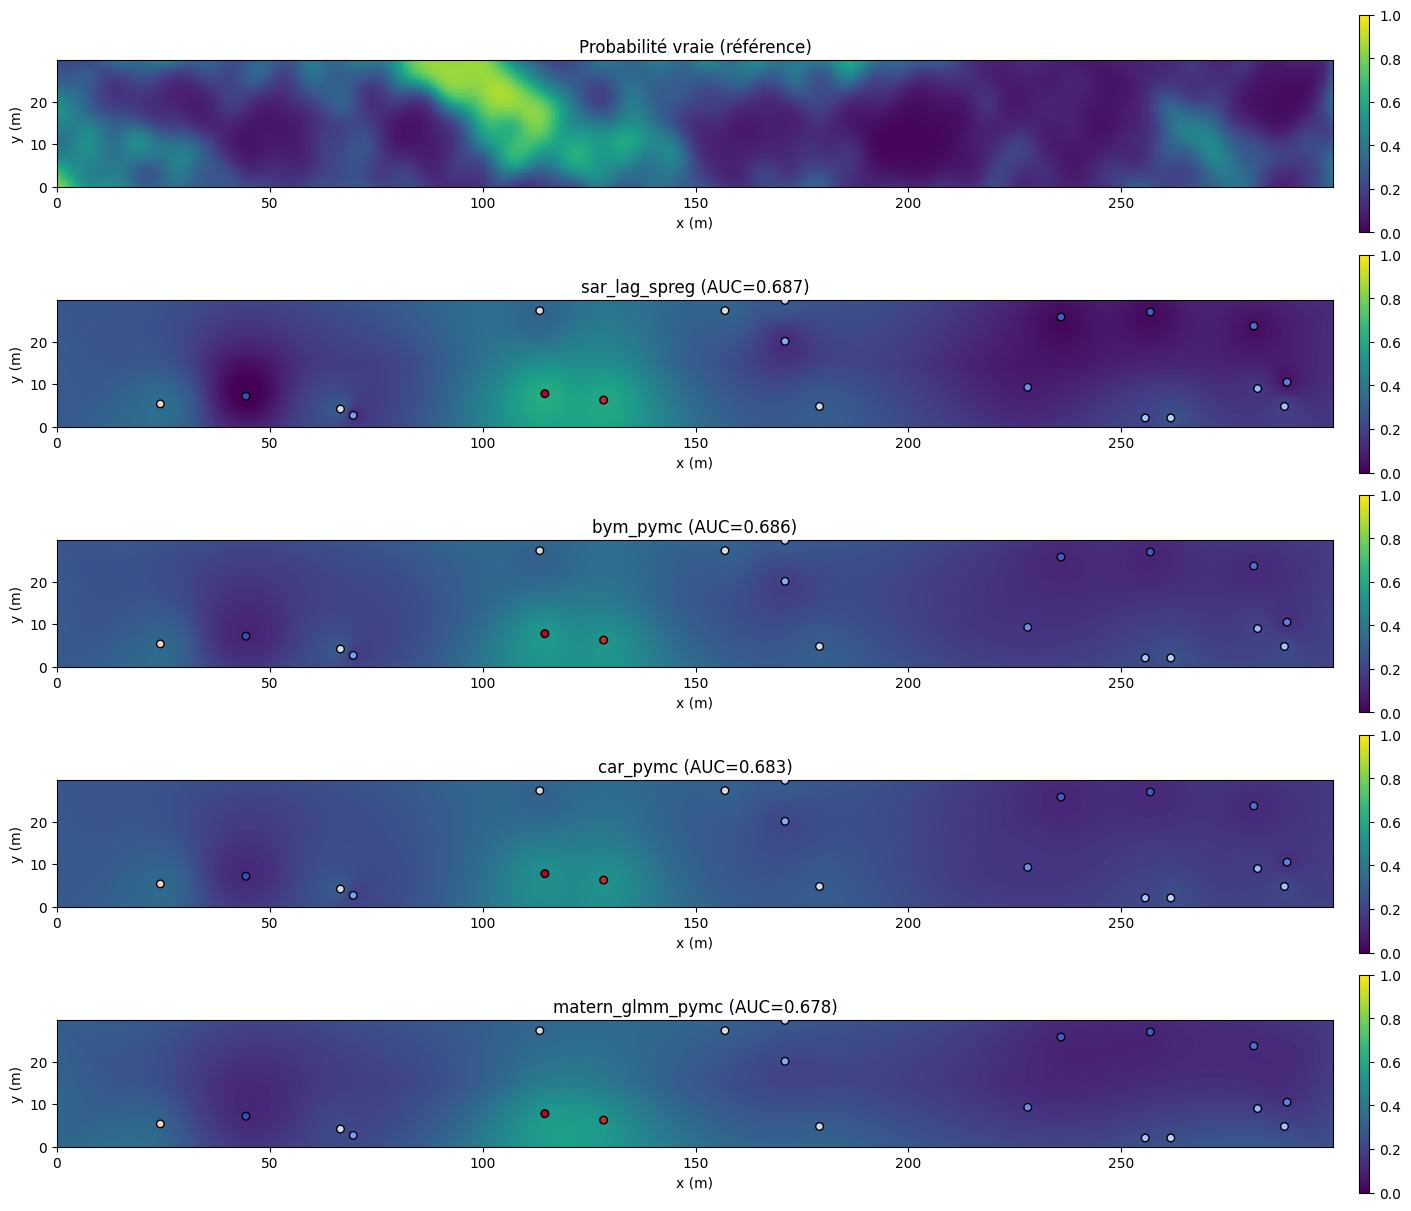

In [3]:
fig, axes = plt.subplots(len(methods) + 1, 1, figsize=(14, 2.4 * (len(methods) + 1)), constrained_layout=True)
plot_field(field, "prob", ax=axes[0], title="Probabilité vraie (référence)")
for ax, name in zip(axes[1:], df["method"].tolist(), strict=True):
    auc = df.set_index("method").loc[name, "auc_roc"]
    plot_prediction(preds[name], field, ax=ax, readings=readings,
                    title=f"{name} (AUC={auc:.3f})")
fig.savefig(FIG_DIR / "05_hierarchical_maps.png", dpi=150)
plt.show()

## C. Diagnostic du GLMM Matérn (ArviZ)

On vérifie la convergence de la chaîne (R-hat, ESS) sur les hyperparamètres
principaux.

In [4]:
import arviz as az

glmm = next(m for m in methods if m.name == "matern_glmm_pymc")
if glmm.trace is not None:
    summary = az.summary(
        glmm.trace, var_names=["beta0", "beta1", "length_scale", "sigma_W"]
    )
    print(summary)
else:
    print("Pas de trace (fallback).")

                mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta0         -1.235   0.356  -1.883   -0.523      0.050    0.030      50.0   
beta1         -0.092   0.145  -0.376    0.180      0.011    0.009     190.0   
length_scale  24.960  10.627   5.871   44.863      0.811    0.474     171.0   
sigma_W        0.890   0.229   0.480    1.307      0.016    0.009     210.0   

              ess_tail  r_hat  
beta0            146.0   1.06  
beta1            136.0   1.01  
length_scale     216.0   1.01  
sigma_W          381.0   1.00  


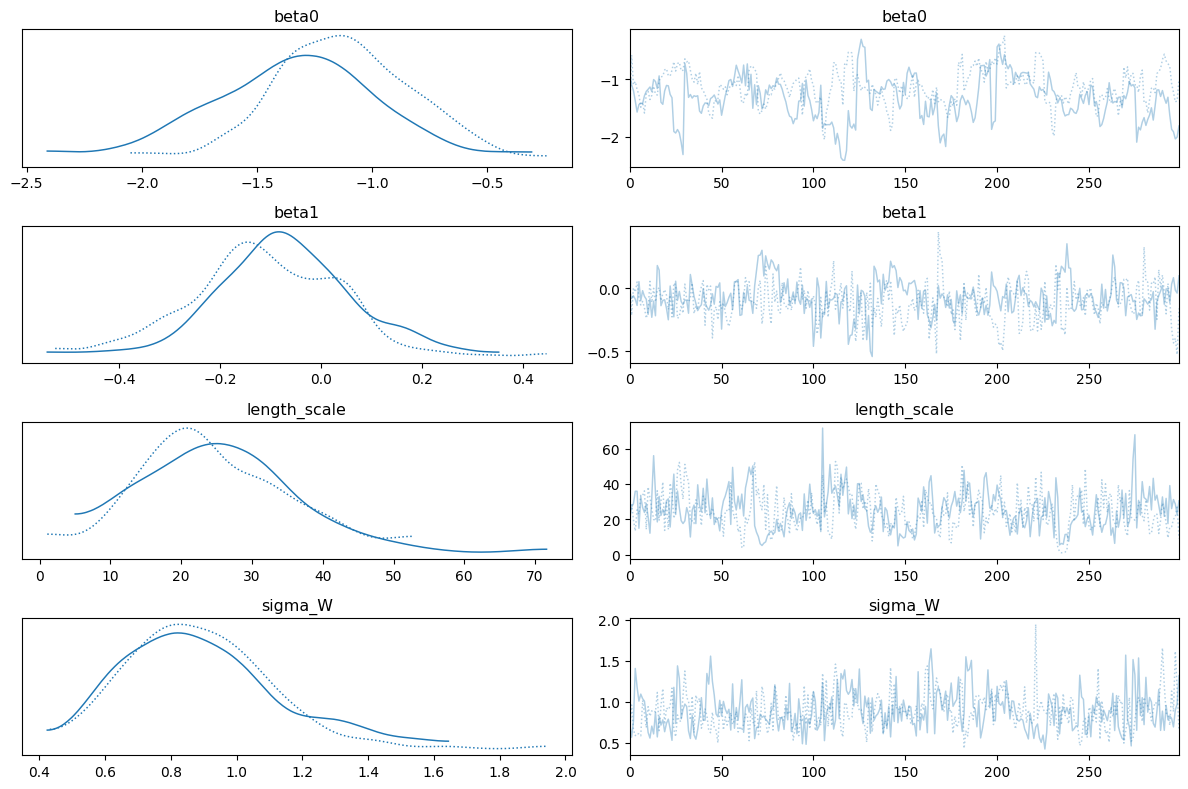

In [5]:
if glmm.trace is not None:
    fig = az.plot_trace(
        glmm.trace, var_names=["beta0", "beta1", "length_scale", "sigma_W"],
        compact=True,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_hierarchical_trace.png", dpi=150)
    plt.show()

## D. Diagnostic SAR Lag

Le coefficient ``ρ`` (corrélation spatiale autorégressive) doit être
significativement non nul pour confirmer une structure spatiale.

In [6]:
sar = next(m for m in methods if m.name == "sar_lag_spreg")
print("Paramètres SAR Lag :")
for k, v in sar.params.items():
    print(f"  {k:>8} = {v:+.4f}")

Paramètres SAR Lag :
       rho = +1.2237
     beta0 = -0.0791
     beta1 = -0.0100
